<a href="https://colab.research.google.com/github/khamersyed68-cyber/F1_Analysis/blob/main/F1_REPORT(1950_2025).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# import pandas,numpy,matplotlib.pyplot,seaborn,matplotlid.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl

In [ ]:
df=pd.read_excel('/content/F1 RACE REPORT (1950-2025).xlsx')

In [ ]:
df.head(76)

,YEAR,Champion,Nationality,Team,Wins,Points,Constructors' Champions,RUNNER-UP,CRASHES,ERA CLASSIFICATION,NO.OF RACES IN YEAR,NO.OF TEAMS,Avg Revenue
0,1950,Giuseppe Farina,Italy,Giuseppe Farina,3,30,NaN,Juan Manuel Fangio,18.0,Front‑Engine Era,7,12,<$10M
1,1951,Juan Manuel Fangio,Argentina,Alfa Romeo,3',31,NaN,Alberto Ascari,18.0,Front‑Engine Era,8,14,<$10M
2,1952,Alberto Ascari,Italy,Ferrari,6',53,NaN,Giuseppe Farina,18.0,Front‑Engine Era,8,15,<$10M
3,1953,Alberto Ascari,Italy,Ferrari,5,34,NaN,Juan Manuel Fangio,18.0,Front‑Engine Era,9,14,<$10M
4,1954,Juan Manuel Fangio,Argentina,Maserati/Mercedes,6,42,NaN,Alberto Ascari,18.0,Front‑Engine Era,9,15,<$10M
...,...,...,...,...,...,...,...,...,...,...,...,...,...
71,2021,Max Verstappen,Netherlands,Red Bull,10,395.5,Mercedes,Lewis Hamilton,29.0,Hybrid Turbo Era,22,10,~$2–2.5B
72,2022,Max Verstappen,Netherlands,Red Bull,15,454,Red Bull,Charles Leclerc,29.0,Ground‑Effect Hybrid Era,22,10,~$3B+
73,2023,Max Verstappen,Netherlands,Red Bull,19,575,Red Bull,Sergio Pérez,29.0,Ground‑Effect Hybrid Era,24,10,~$3B+
74,2024,Max Verstappen,Netherlands,Red Bull,18,560,McLaren,Lando Norris,29.0,Ground‑Effect Hybrid Era,24,10,~$3B+


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76 entries, 0 to 75
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   YEAR                     76 non-null     int64  
 1   Champion                 76 non-null     object 
 2   Nationality              75 non-null     object 
 3   Team                     76 non-null     object 
 4   Wins                     74 non-null     object 
 5   Points                   76 non-null     object 
 6   Constructors' Champions  68 non-null     object 
 7   RUNNER-UP                76 non-null     object 
 8   CRASHES                  73 non-null     float64
 9   ERA CLASSIFICATION       76 non-null     object 
 10  NO.OF RACES IN YEAR      74 non-null     object 
 11  NO.OF TEAMS              76 non-null     object 
 12  Avg Revenue              76 non-null     object 
dtypes: float64(1), int64(1), object(11)
memory usage: 7.8+ KB


In [ ]:
backup = df.copy()

In [ ]:
# removing null  values
print(df.isnull().sum(0))

YEAR                       0
Champion                   0
Nationality                1
Team                       0
Wins                       2
Points                     0
Constructors' Champions    8
RUNNER-UP                  0
CRASHES                    3
ERA CLASSIFICATION         0
NO.OF RACES IN YEAR        2
NO.OF TEAMS                0
Avg Revenue                0
dtype: int64


In [ ]:
df = df.fillna(0)

In [ ]:
df['Wins'].unique()

array([3, "3'", "6'", 5, 6, 4, '4 wins', 1, 2, 7, "2'", 0, '3"', 8, 9,
       "7'", 11, 13, "11'", 10, 15, 19, 18], dtype=object)

In [ ]:
df['Wins']=df['Wins'].dropna()

In [ ]:
# Convert to string to handle mixed types safely
df['Wins'] = df['Wins'].astype(str)

# Remove 'wins', quotes, and commas
# The order of these operations matters
df['Wins'] = df['Wins'].str.replace('wins', '', regex=False)
df['Wins'] = df['Wins'].str.replace("'", '', regex=False)
df['Wins'] = df['Wins'].str.replace('"', '', regex=False)
df['Wins'] = df['Wins'].str.replace(',', '', regex=False)

# Handle cases where there might be spaces (e.g., '4  ' after cleaning)
df['Wins'] = df['Wins'].str.strip()

# Convert to numeric, coercing errors (like empty strings or remaining non-numbers) to NaN
df['Wins'] = pd.to_numeric(df['Wins'], errors='coerce')

# Fill any remaining NaN values with 0
df['Wins'] = df['Wins'].fillna(0)

# Finally, convert to integer
df['Wins'] = df['Wins'].astype(int)
df['Wins'].unique()

array([ 3,  6,  5,  4,  1,  2,  7,  0,  8,  9, 11, 13, 10, 15, 19, 18])

In [ ]:
df['Wins'].unique()

array([ 3,  6,  5,  4,  1,  2,  7,  0,  8,  9, 11, 13, 10, 15, 19, 18])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76 entries, 0 to 75
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   YEAR                     76 non-null     int64  
 1   Champion                 76 non-null     object 
 2   Nationality              76 non-null     object 
 3   Team                     76 non-null     object 
 4   Wins                     76 non-null     int64  
 5   Points                   76 non-null     object 
 6   Constructors' Champions  76 non-null     object 
 7   RUNNER-UP                76 non-null     object 
 8   CRASHES                  76 non-null     float64
 9   ERA CLASSIFICATION       76 non-null     object 
 10  NO.OF RACES IN YEAR      76 non-null     object 
 11  NO.OF TEAMS              76 non-null     object 
 12  Avg Revenue              76 non-null     object 
dtypes: float64(1), int64(2), object(10)
memory usage: 7.8+ KB


In [ ]:
df['Points'].unique()

array([30, 31, 53, 34, 42, 40, 43, 54, 51, 48, 63, 45, 62, 61, 71, 55, 64,
       69, '72 points', 50, 44, 59, 72, 73, 90, 76, 78, 96, 108, 99, 92,
       102, 97, 81, 100, 123, 144, 93, 148, 133, 134, 110, 98, 95, 256,
       392, 281, 397, 384, 381, 385, 363, 408, 413, 347, 395.5, 454, 575,
       560, 423], dtype=object)

In [ ]:
# Convert to string to handle mixed types safely
df['Points'] = df['Points'].astype(str)

# Remove 'wins', quotes, and commas
# The order of these operations matters
df['Points'] = df['Points'].str.replace('points', '', regex=False)
df['Points'] = df['Points'].str.replace("'", '', regex=False)
df['Points'] = df['Points'].str.replace('"', '', regex=False)
df['Points'] = df['Points'].str.replace(',', '', regex=False)

# Convert to numeric, coercing errors (like empty strings or remaining non-numbers) to NaN
df['Points'] = pd.to_numeric(df['Points'], errors='coerce')

# Fill any remaining NaN values with 0
df['Points'] = df['Points'].fillna(0)

# Finally, convert to integer
df['Points'] = df['Points'].astype(int)
df['Points'].unique()

array([ 30,  31,  53,  34,  42,  40,  43,  54,  51,  48,  63,  45,  62,
        61,  71,  55,  64,  69,  72,  50,  44,  59,  73,  90,  76,  78,
        96, 108,  99,  92, 102,  97,  81, 100, 123, 144,  93, 148, 133,
       134, 110,  98,  95, 256, 392, 281, 397, 384, 381, 385, 363, 408,
       413, 347, 395, 454, 575, 560, 423])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76 entries, 0 to 75
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   YEAR                     76 non-null     int64  
 1   Champion                 76 non-null     object 
 2   Nationality              76 non-null     object 
 3   Team                     76 non-null     object 
 4   Wins                     76 non-null     int64  
 5   Points                   76 non-null     int64  
 6   Constructors' Champions  76 non-null     object 
 7   RUNNER-UP                76 non-null     object 
 8   CRASHES                  76 non-null     float64
 9   ERA CLASSIFICATION       76 non-null     object 
 10  NO.OF RACES IN YEAR      76 non-null     object 
 11  NO.OF TEAMS              76 non-null     object 
 12  Avg Revenue              76 non-null     object 
dtypes: float64(1), int64(3), object(9)
memory usage: 7.8+ KB


In [ ]:
df['CRASHES'].unique()

array([18., 21.,  0., 40., 65., 58., 30., 29.])

In [ ]:
df['CRASHES'] = df['CRASHES'].astype(int)
df['CRASHES'].unique()

array([18, 21,  0, 40, 65, 58, 30, 29])

In [ ]:
df['NO.OF RACES IN YEAR'].unique()

array([7, 8, 9, 11, 0, 10, 12, 13, 15, 14, 16, 17, '"17dde', 18, 19, 20,
       'faha', 21, '17 (COVID‑affected)', 22, 24, '23 (planned)'],
      dtype=object)

In [ ]:
df['NO.OF RACES IN YEAR'] = df['NO.OF RACES IN YEAR'].astype(str)
df['NO.OF RACES IN YEAR'] = df['NO.OF RACES IN YEAR'].str.extract(r'(\d+)')
df = df.dropna(subset=['NO.OF RACES IN YEAR'])
df['NO.OF RACES IN YEAR'] = df['NO.OF RACES IN YEAR'].astype(int)
print(df['NO.OF RACES IN YEAR'].dtype)
print(df['NO.OF RACES IN YEAR'].head(76))
df['NO.OF RACES IN YEAR'].unique()

int64
0      7
1      8
2      8
3      9
4      9
      ..
71    22
72    22
73    24
74    24
75    23
Name: NO.OF RACES IN YEAR, Length: 75, dtype: int64


array([ 7,  8,  9, 11,  0, 10, 12, 13, 15, 14, 16, 17, 18, 19, 20, 21, 22,
       24, 23])

In [ ]:
df['NO.OF TEAMS'].unique()

array([12, 14, 15, 13, 18, 16, 17, 20, 21, 19, '26 (peak)', 25, 24, 11,
       10, '11 (Haas joined)'], dtype=object)

In [ ]:
df['NO.OF TEAMS'] = df['NO.OF TEAMS'].astype(str)
df['NO.OF TEAMS'] = df['NO.OF TEAMS'].str.extract(r'(\d+)')
df = df.dropna(subset=['NO.OF TEAMS'])
df['NO.OF TEAMS'] = df['NO.OF TEAMS'].astype(int)
print(df['NO.OF TEAMS'].dtype)
print(df['NO.OF TEAMS'].head(76))
df['NO.OF TEAMS'].unique()

int64
0     12
1     14
2     15
3     14
4     15
      ..
71    10
72    10
73    10
74    10
75    10
Name: NO.OF TEAMS, Length: 75, dtype: int64


array([12, 14, 15, 13, 18, 16, 17, 20, 21, 19, 26, 25, 24, 11, 10])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 75 entries, 0 to 75
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   YEAR                     75 non-null     int64 
 1   Champion                 75 non-null     object
 2   Nationality              75 non-null     object
 3   Team                     75 non-null     object
 4   Wins                     75 non-null     int64 
 5   Points                   75 non-null     int64 
 6   Constructors' Champions  75 non-null     object
 7   RUNNER-UP                75 non-null     object
 8   CRASHES                  75 non-null     int64 
 9   ERA CLASSIFICATION       75 non-null     object
 10  NO.OF RACES IN YEAR      75 non-null     int64 
 11  NO.OF TEAMS              75 non-null     int64 
 12  Avg Revenue              75 non-null     object
dtypes: int64(6), object(7)
memory usage: 8.2+ KB


In [ ]:
df['Avg Revenue'].unique()

array(['<$10M', '~$20M', '~$50M', '~$200M', '~$500M', '~$1B', '~$1.5B',
       '~$2–2.5B', '~$3B+'], dtype=object)

In [ ]:
print(df['Avg Revenue'].dtype)

object


In [ ]:
df['Avg Revenue'] = df['Avg Revenue'].astype(str)

df['Avg Revenue'] = df['Avg Revenue'].str.replace('$', '', regex=False)
df['Avg Revenue'] = df['Avg Revenue'].str.replace('M', '', regex=False)
df['Avg Revenue'] = pd.to_numeric(df['Avg Revenue'], errors='coerce')
df['Avg Revenue'] = df['Avg Revenue'].astype(float)
df = df.dropna(subset=['Avg Revenue'])
df['Avg Revenue'] = df['Avg Revenue'].astype(int)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 0 entries
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   YEAR                     0 non-null      int64 
 1   Champion                 0 non-null      object
 2   Nationality              0 non-null      object
 3   Team                     0 non-null      object
 4   Wins                     0 non-null      int64 
 5   Points                   0 non-null      int64 
 6   Constructors' Champions  0 non-null      object
 7   RUNNER-UP                0 non-null      object
 8   CRASHES                  0 non-null      int64 
 9   ERA CLASSIFICATION       0 non-null      object
 10  NO.OF RACES IN YEAR      0 non-null      int64 
 11  NO.OF TEAMS              0 non-null      int64 
 12  Avg Revenue              0 non-null      int64 
dtypes: int64(7), object(6)
memory usage: 0.0+ bytes


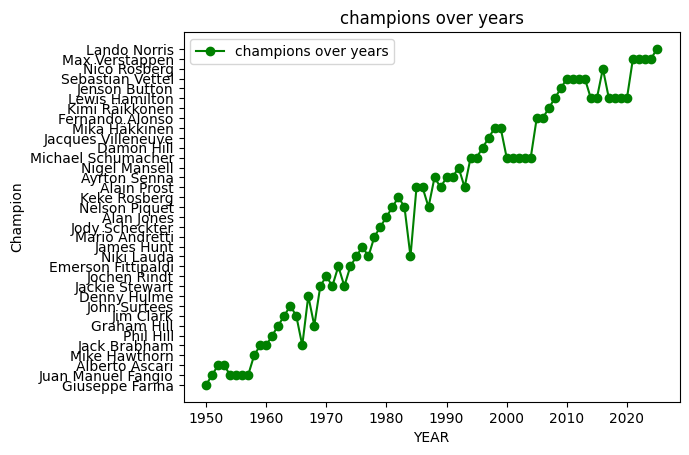

In [ ]:
# The original df is empty due to previous operations, so we'll use the backup DataFrame for data.
# The 'x' and 'y' variables were not defined, causing the NameError.
x = backup['YEAR']
y = backup['Champion']

plt.plot(x, y, color='green', marker='o', label='champions over years')

plt.xlabel("YEAR")
plt.ylabel("Champion")
plt.title("champions over years")
plt.legend()

plt.show()

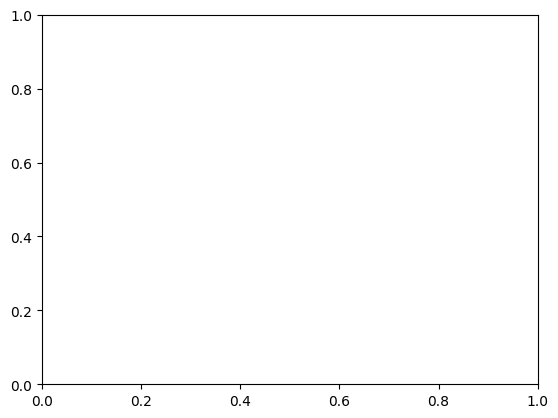

In [ ]:
sns.boxplot(x="Champion", y="YEAR", data=df)
plt.show()

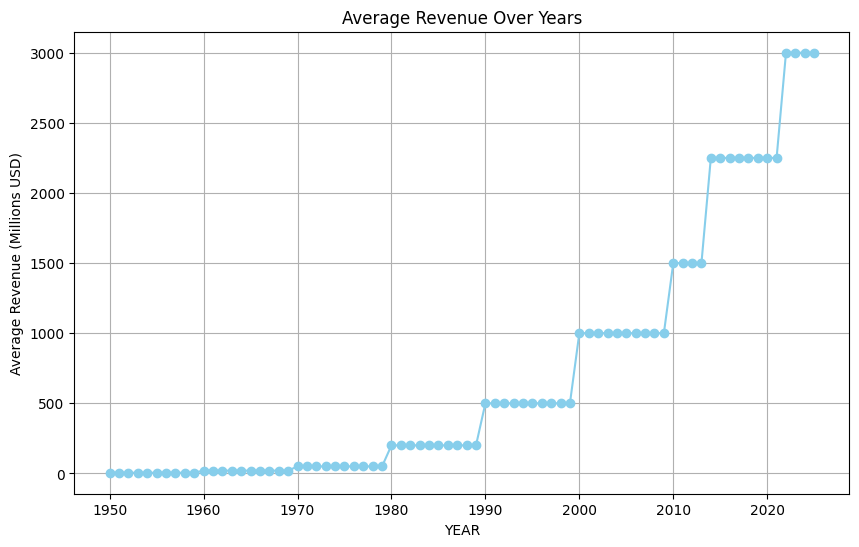

In [ ]:
# Apply the conversion to the 'Avg Revenue' column in the backup DataFrame
backup['Avg Revenue_Numeric'] = backup['Avg Revenue'].apply(convert_revenue_to_numeric)

plt.figure(figsize=(10, 6))
plt.plot(backup['YEAR'], backup['Avg Revenue_Numeric'], marker='o', linestyle='-', color='skyblue')
plt.xlabel('YEAR')
plt.ylabel('Average Revenue (Millions USD)')
plt.title('Average Revenue Over Years')
plt.grid(True)
plt.show()